# 04 — Performance indicators of the pipeline

The KPIs answer three questions: is the data **good**, is the pipeline **fast and thrifty**,
and is the dataset **growing**? The matching interactive dashboard is `src/multimodal_etl/dashboard.py`.

In [1]:
from dotenv import load_dotenv

from multimodal_etl.logging_setup import setup_logging
from multimodal_etl.utils.paths import ROOT_DIR

# No `sys.path` insert: the project is installed in the environment `uv run` provides, and a
# notebook that patches the path hides which interpreter it is actually running against.
load_dotenv(ROOT_DIR / ".env")
setup_logging()

## 1. Load the artefacts of the last run

Three pieces: the dataset, its transformation statistics, and the record of the last run.

In [2]:
from multimodal_etl.kpi import compute_kpis, load_latest_dataset

df, stats, run = load_latest_dataset()
print(
    f"{len(df)} publications in the latest dataset, "
    f"produced by the run of {run.get('date', 'an undated run')}"
)
kpis = compute_kpis(df, stats, run)

131 publications in the latest dataset, produced by the run of an undated run


## 2. Data quality

The text-image pairing rate matters most: it is the very definition of the dataset. The
share of dated publications counts too — without a date, no freshness measurement is
possible.

In [3]:
kpis["quality"]

{'validity_rate_pct': 76.6,
 'text_image_pairing_pct': 100.0,
 'labelled_rate_pct': 24.4,
 'duplicate_rate_pct': 0.0,
 'dated_rate_pct': 93.9,
 'mean_text_length': 304.3}

## 3. Volume and diversity

The share of the dominant source deserves an explanation: a dataset captured 80% by a
single publisher passes its editorial bias on to the model. So we watch the concentration,
not only the volume.

In [4]:
kpis["volume"]

{'publications': 131,
 'sources': 5,
 'dominant_source_share_pct': 34.4,
 'by_source': {'rss:the_guardian': 45,
  'rss:bbc_news': 29,
  'rss:abc_news': 25,
  'fakeddit': 24,
  'fakenewsnet:gossipcop': 8},
 'by_language': {'en': 131},
 'by_access_method': {'rss_feed': 99,
  'kaggle_download': 24,
  'github_download': 8}}

## 4. Freshness

A fake-news detector has to see recent news. If the median age climbs, the feed has frozen
and we are re-ingesting the past.

In [5]:
kpis["freshness"]

{'median_age_hours': 21.7, 'under_24h_pct': 58.5, 'dated_publications': 123}

## 5. Performance and cost

Speed (duration per step, throughput), cost (API calls spent from the quota, disk taken up
by the images) and what the run really adds.

In [6]:
kpis["performance"]

{'extract_duration_sec': 56.48,
 'transform_duration_sec': 0.26,
 'load_duration_sec': 0.06,
 'total_duration_sec': 56.8,
 'publications_per_sec': 2.9,
 'api_calls_spent': 0,
 'image_weight_mb': 10.33,
 'images_downloaded_pct': 96.9,
 'new_rate_pct': 0.0,
 'publications_added': 0,
 'publications_in_db': 123,
 'failed_sources': 0}

## 6. Checking against the thresholds

The thresholds are defined in `multimodal_etl.kpi.THRESHOLDS`, each with its rationale. The
monitoring plan and the dashboard read the same dictionary: the document cannot drift out
of sync with the application.

In [7]:
import pandas as pd

from multimodal_etl.kpi import evaluate_thresholds

pd.DataFrame(evaluate_thresholds(kpis))[["label", "value", "expected", "status", "justification"]]

,label,value,expected,status,justification
0,Validity rate,76.6,≥ 60 %,green,Set on the observed behaviour (around 65%): a ...
1,Text-image pairing,100.0,≥ 90 %,green,This is the very definition of the dataset: wi...
2,Duplicate rate,0.0,≤ 5 %,green,"A climbing rate signals over-ingestion, or an ..."
3,Volume ingested,131.0,≥ 80 publications,green,A collapsing volume gives away a source that i...
4,Share of the dominant source,34.4,≤ 50 %,green,A dataset captured by a single source passes i...
5,Median age,21.7,≤ 48 h,green,"A fake-news detector has to see recent news, n..."
6,Total duration,56.8,≤ 90 s,green,"Beyond that, the daily execution window ends u..."
7,Images downloaded,96.9,≥ 80 %,green,Measures media availability: an announced URL ...
8,Failed sources,0.0,≤ 0 sources,green,Two silent sources on the same day is an incid...


## 7. Charts

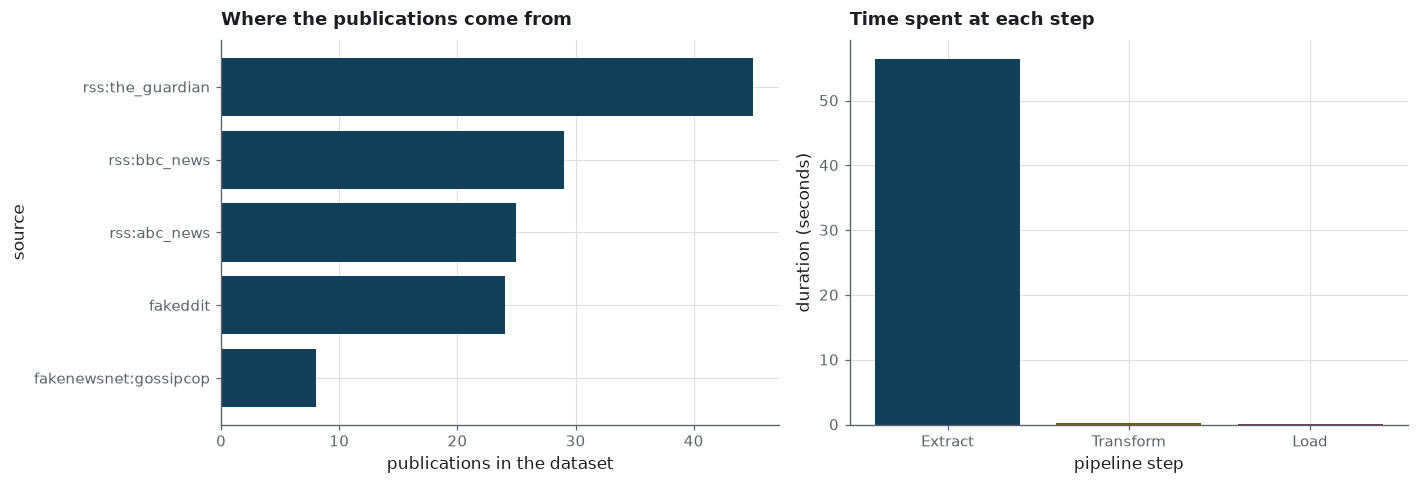

In [8]:
import matplotlib.pyplot as plt

from multimodal_etl.figure_style import PALETTE, apply_style, save_figure, series_colours

apply_style()

by_source = kpis["volume"]["by_source"]
steps = ["Extract", "Transform", "Load"]
durations = [
    kpis["performance"]["extract_duration_sec"],
    kpis["performance"]["transform_duration_sec"],
    kpis["performance"]["load_duration_sec"],
]
colours = series_colours(steps)

figure, (left, right) = plt.subplots(1, 2, figsize=(13, 4.5))
left.barh(
    list(by_source.keys())[::-1],
    list(by_source.values())[::-1],
    color=PALETTE["primary"],
)
left.set_title("Where the publications come from")
left.set_xlabel("publications in the dataset")
left.set_ylabel("source")

right.bar(steps, durations, color=[colours[step] for step in steps])
right.set_title("Time spent at each step")
right.set_xlabel("pipeline step")
right.set_ylabel("duration (seconds)")

figure.tight_layout()
plt.show()

## 8. Run history

The table below is one row per run, in order. A rate of 80 % at the top of a rising column and
at the bottom of a falling one are two different situations, and only the second calls for
anything.

In [9]:
from multimodal_etl.kpi import run_history

history = run_history()
history[
    [
        "date",
        "orchestrator",
        "publications_extracted",
        "publications_added",
        "publications_in_db",
        "total_duration_sec",
        "validity_rate_pct",
    ]
]

,date,orchestrator,publications_extracted,publications_added,publications_in_db,total_duration_sec,validity_rate_pct
0,2026-09-03 07:16:50+00:00,script,164,112,112,87.61,68.3
1,2026-09-03 07:18:05+00:00,script,164,12,124,56.85,74.4
2,2026-09-03 07:43:36+00:00,script,164,123,123,60.20,75.0
3,2026-09-03 07:44:33+00:00,script,164,0,123,56.80,75.0


The number of publications added falls from one run to the next while the total in the
database grows: the load is **incremental**, only the publications still unknown get
written. That is exactly what a daily ingestion is expected to do.